# Geological Modeling with GemPy - Tharsis AOI 1

This notebook demonstrates 3D geological modeling using GemPy for the Tharsis Area of Interest 1. The workflow includes data preprocessing, model creation, and visualization of geological structures.

## 1. Import Required Libraries and Setup Configuration

Import necessary libraries for geological modeling, data processing, and visualization.

In [2]:
import os
import threading
import gempy as gp
import pandas as pd
import HelperMethods

# Setup base directory
BASE_DIR = os.getcwd()
print(f"Base directory: {BASE_DIR}")

Base directory: c:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel


## 2. Define File Paths and Model Parameters

Set up all file paths for input data and define model configuration parameters.

In [3]:
# Define data directory and file paths
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

path_to_data = os.path.join(data_dir, 'formationinputpoints_reduced.csv')
path_to_orientations = os.path.join(data_dir, 'orientations_reduced.csv')
path_to_topography = os.path.join(data_dir, 'topo.tif')
path_to_topography_cleaned = os.path.join(data_dir, 'topo_cleaned.tif')
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced.tif')

# Model parameters
invalid_below = -100  # Define what we consider invalid topography
model_depth = -500  # Define the depth of the model
topo_reduction_factor = 0.1  # Define the factor by which to reduce the topography resolution

# Processing triggers
trigger_create_cross_section = True  # Set to True if you want to create a cross section
trigger_drop_lithologies = False  # Set to True if you want to drop certain lithologies

# Lithologies to optionally drop
lithologies_to_drop = [
    "Upper Carboniferous Volcanics",
    "Tournaisian Plutonites"
]

print("File paths and parameters configured successfully!")

File paths and parameters configured successfully!


## 3. Load and Examine Input Data

Load CSV files containing formation points and orientation data, then examine the data structure and calculate bounding box coordinates.

In [4]:
# Load geological data
points_df = pd.read_csv(path_to_data, encoding='latin1', engine='python')
orientations_df = pd.read_csv(path_to_orientations, encoding='latin1', engine='python')

print("Data loaded successfully!")
print(f"Formation points shape: {points_df.shape}")
print(f"Orientations shape: {orientations_df.shape}")

# Display first few rows
print("\nFormation points (first 5 rows):")
display(points_df.head())

print("\nOrientations (first 5 rows):")
display(orientations_df.head())

Data loaded successfully!
Formation points shape: (4, 5)
Orientations shape: (7, 8)

Formation points (first 5 rows):


,X,Y,Z,formation,formation_id
0,-697098,4543927,271,Upper Devonian Siliciclastics,40
1,-705656,4548904,357,Mid Carboniferous Shales,76
2,-700314,4545329,346,Upper Devonian Siliciclastics,40
3,-704835,4530651,344,Visean Shales,67



Orientations (first 5 rows):


,X,Y,Z,azimuth,dip,polarity,formation,formation_id
0,-697098,4543927,271,284,55,-1,Upper Devonian Siliciclastics,40
1,-681850,4530352,161,286,47,-1,Upper Devonian Siliciclastics,40
2,-681855,4530372,286,318,30,-1,Upper Devonian Siliciclastics,40
3,-705656,4548904,357,134,38,-1,Mid Carboniferous Shales,76
4,-704549,4547233,500,105,30,-1,Upper Devonian Siliciclastics,40


In [5]:
# Define coordinate bounds from the data
top_right = (-678192, 4549947)
bottom_right = (-677518, 4529455)
bottom_left = (-706792, 4528453)
top_left = (-707522, 4548927)

# Calculate bounding box of the area of interest
min_x = min(top_left[0], bottom_left[0])
max_x = max(top_right[0], bottom_right[0])
min_y = min(bottom_left[1], bottom_right[1])
max_y = max(top_left[1], top_right[1])
max_z = points_df['Z'].max()

print(f"Bounding box calculated:")
print(f"X range: {min_x} to {max_x}")
print(f"Y range: {min_y} to {max_y}")
print(f"Z range: {model_depth} to {max_z}")

Bounding box calculated:
X range: -707522 to -677518
Y range: 4528453 to 4549947
Z range: -500 to 357


## 4. Clean and Preprocess Topography Data

Process the topography data by cleaning invalid values and reducing resolution for computational efficiency.

In [6]:
# Clean topography file
print("Cleaning topography file...")
HelperMethods.clean_topo_file(path_to_topography, path_to_topography_cleaned)

# Reduce topography resolution
print(f"Reducing topography resolution by factor {topo_reduction_factor}...")
HelperMethods.reduce_tif_resolution(
    input_path=path_to_topography_cleaned,
    output_path=path_to_topography_reduced,
    scale_factor=topo_reduction_factor
)

# Update path with scale factor suffix
base, ext = os.path.splitext(path_to_topography_reduced)
path_to_topography_reduced = f"{base}_sf{topo_reduction_factor}{ext}"

print(f"Processed topography saved to: {path_to_topography_reduced}")

Cleaning topography file...
Reducing topography resolution by factor 0.1...
Processed topography saved to: c:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel\..\Data\Tharsis AOI 1\topo_reduced_sf0.1.tif


## 5. Filter Lithologies (Optional)

Optionally remove specified lithologies from the dataset based on trigger settings.

In [7]:
# Conditionally drop lithologies
if trigger_drop_lithologies:
    print("Dropping specified lithologies...")
    print(f"Lithologies to drop: {lithologies_to_drop}")
    HelperMethods.drop_lithologies(points_df, orientations_df, lithologies_to_drop)
    print("Lithologies dropped successfully!")
else:
    print("Lithology filtering is disabled - keeping all lithologies")

Lithology filtering is disabled - keeping all lithologies


## 6. Create GemPy Geological Model

Initialize the geological model using GemPy with specified extent, refinement, and input data.

In [8]:
# Create the geological model
print("Creating GemPy geological model...")

geo_model = gp.create_geomodel(
    project_name='AOI',
    extent=[min_x, max_x, max_y, min_y, model_depth, max_z],
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=os.path.join(BASE_DIR, "temp_orientations.csv"),
        path_to_surface_points=os.path.join(BASE_DIR, "temp_points.csv"),
    )
)

print("Geological model created successfully!")

Creating GemPy geological model...
Geological model created successfully!


## 7. Configure Model Stack and Surfaces

Map geological stacks to surfaces and apply color schemes to lithologies.

In [9]:
# Map geological stacks to surfaces
print("Configuring geological stacks and surfaces...")

gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        # Alternative configurations (commented):
        #"Strat_Series2": ("Visean Shales", "Mid Carboniferous Shales"),
        #"Strat_Series2": ("Upper Carboniferous Volcanics", "Visean Shales"),
        #"Strat_Series2": "Tournaisian Plutonites",
        "Strat_Series1": ("Mid Carboniferous Shales", "Visean Shales", "Upper Devonian Siliciclastics")
    }
)

# Apply color scheme to lithologies
print("Applying color scheme to lithologies...")
HelperMethods.color_lithology(geo_model.structural_frame.structural_elements)

print("Model configuration completed!")

Configuring geological stacks and surfaces...
Applying color scheme to lithologies...
Model configuration completed!


## 8. Set Topography and Compute Model

Apply topography from the processed file to the model grid and compute the geological model.

In [10]:
# Set topography from processed file
print("Setting topography...")
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_reduced)

# Compute the geological model
print("Computing geological model... (this may take a while)")
gempy_model = gp.compute_model(geo_model)

print("Model computation completed successfully!")

Setting topography...
Active grids: GridTypes.NONE|TOPOGRAPHY|OCTREE
Computing geological model... (this may take a while)
Setting Backend To: AvailableBackends.numpy


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 9 chunks
Chunking done: 8 chunks
Model computation completed successfully!


## 9. Visualize 3D Model

Create 3D visualization of the geological model using asynchronous plotting.

In [11]:
# Create 3D visualization (asynchronous)
print("Starting 3D visualization...")
threading.Thread(target=HelperMethods.plot_3d_async, args=(geo_model,)).start()

print("3D visualization initiated! Check for the plotting window.")

Starting 3D visualization...
3D visualization initiated! Check for the plotting window.


## 10. Create Cross Sections

Generate cross-sectional views of the geological model when enabled.

Creating cross section...


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:17

Cross section created!


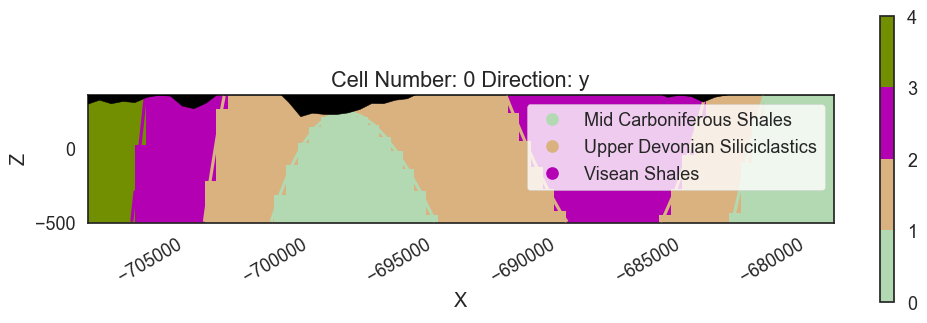

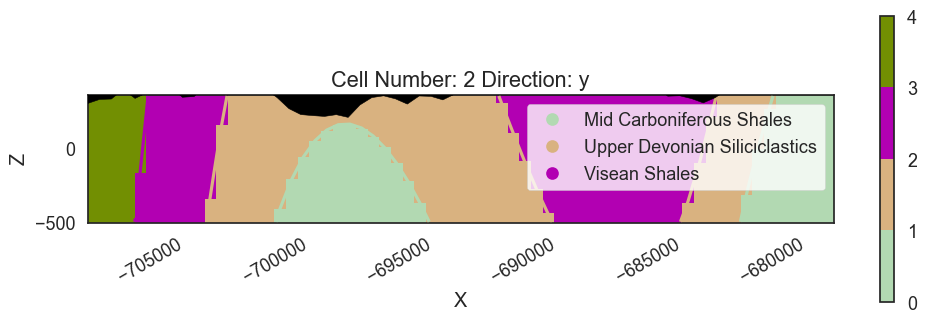

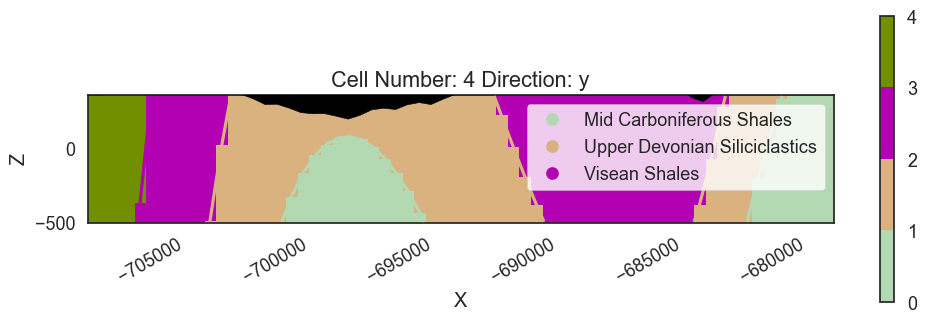

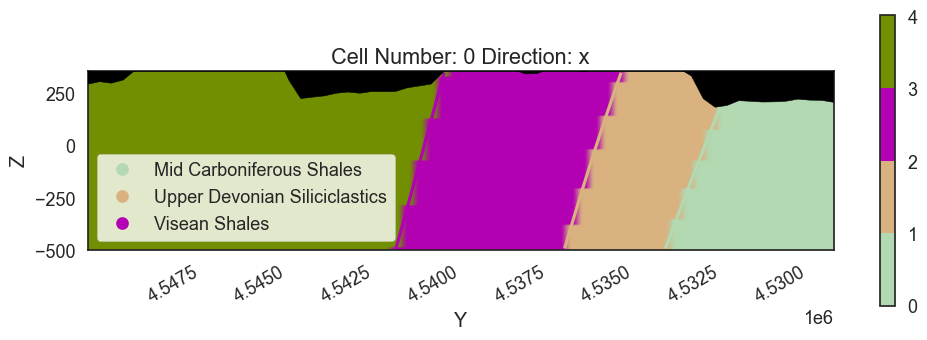

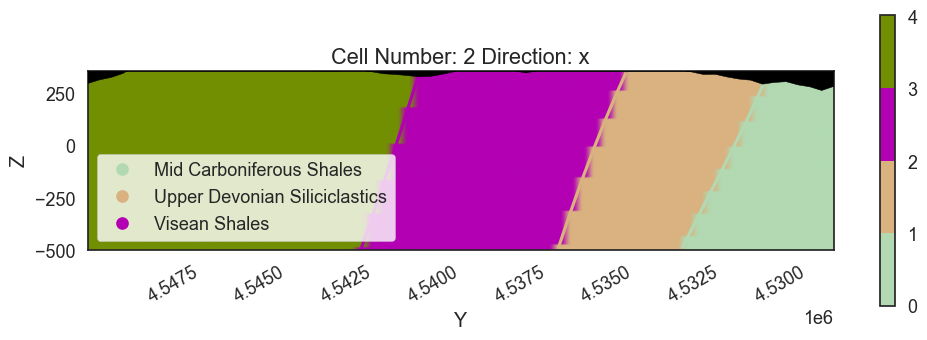

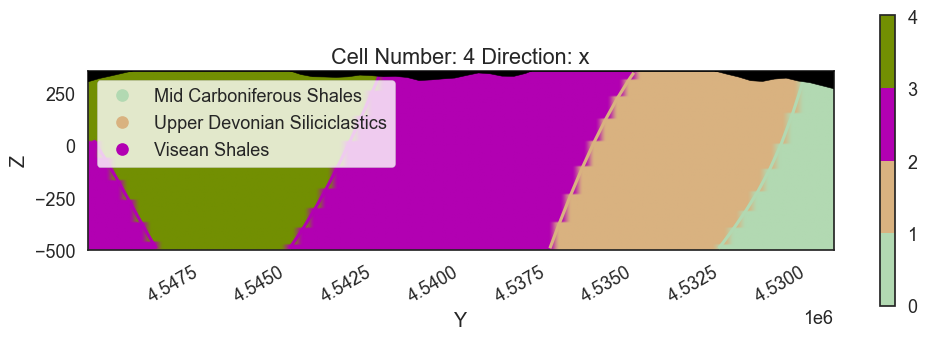

In [12]:
# Create cross sections if enabled
if trigger_create_cross_section:
    print("Creating cross section...")
    HelperMethods.create_cross_section(geo_model, cross_section=5)
    print("Cross section created!")
else:
    print("Cross section creation is disabled")

## Completion

The geological modeling workflow for Tharsis AOI 1 is now complete! The notebook has:

1. ✅ Loaded and preprocessed geological data
2. ✅ Cleaned and reduced topography resolution 
3. ✅ Created a 3D geological model using GemPy
4. ✅ Applied surface mappings and color schemes
5. ✅ Generated visualizations and cross-sections

### Additional Visualization Options

The commented code below shows alternative plotting methods that can be used for further analysis:

In [ ]:
# Additional visualization options (uncomment to use):

"""
# 2D plotting with scalar values
gpv.plot_2d(geo_model, show_value=True, show_lith=False, show_scalar=True, legend=False)

# 2D plotting in Z direction
gpv.plot_2d(geo_model, show_boundaries=False, show_data=False, direction="z", legend=False)

# Set alternative topography and plot 3D
gp.set_topography_from_file(grid=geo_model.grid, filepath=path_to_topography_cleaned)
gpv.plot_3d(geo_model, show_lith=True, show_boundaries=True, ve=20, legend=False, show_data=True)

# Modify structural groups for focused analysis
geo_model.structural_frame.structural_groups = geo_model.structural_frame.structural_groups[1:2]

# Adjust Z-scale for better visualization
geo_model.input_transform.scale[2] *= 2
"""

print("Geological modeling workflow completed successfully!")
print("Use the commented visualization options above for additional analysis.")